# Experiment 2.2 — Phase B width sweep under explicit relative-time readout

## Scientific question

Experiment 2.1.1 showed two distinct mechanisms:

- `timestep_ce` retained most of its performance after 200/500 ms block-order shuffling, consistent with strong local/intermediate class evidence plus segment-level accumulation.
- `relative_10bin_ce` collapsed when input block order or post-SNN relative-bin identity was destroyed, showing that **gesture-phase identity is a major source of discriminative information**.

Therefore Phase B does **not** ask whether the feed-forward SNN itself has long-term memory. It asks:

> **How much feed-forward SNN backbone capacity is required when the classifier explicitly preserves relative gesture phase?**

The objective/readout is configured by `LOSS_OBJECTIVE` using the two canonical losses from Experiment 2.1.1.

### Width protocol

- Reference architecture from Experiment 2.1/2.1.1: **2 hidden layers × 64 neurons**.
- Fixed depth: **2**.
- Width sweep: **64, 128, 256**.
- We deliberately do not sweep below 64; this is a capacity/saturation study, not a minimum-model-size study.
- Single fixed Synaptic-LIF time scale; no recurrence.
- Same split, five master seeds, optimizer, 150-epoch budget, and best-validation-BA checkpoint rule as Experiment 2.1.1.
- Width is selected using **mean validation balanced accuracy across seeds**. Test data are not used in this notebook for architecture selection.

The selected width is written to `selected_width.json` for Experiment 2.3.

The model initialization keys are intentionally inherited from Experiment 2.1.1, so the **2×64** anchor uses the same initialization protocol as the prior `relative_10bin_ce` run.

In [60]:
from __future__ import annotations

from pathlib import Path
import copy, hashlib, json, math, os, random, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

import snntorch as snn
from snntorch import surrogate
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the writingRing repository root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
CUDA available: True


## 1. Configuration

In [61]:
DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64",
    REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64",
]

INCLUDED_LABELS = (
    "A", "B", "C", "D", "E", "X",
    "G", "H", "I", "J", "K", "L",
)

SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
SEEDS = (11, 23, 101) #11, 23, 101, 40, 231

# Select the loss/readout inherited from Experiment 2.1.1.
LOSS_OBJECTIVE = "relative10bin-ce"  # "timesteps-ce" or "relative10bin-ce"
LOSS_OBJECTIVE_ALIASES = {
    "timesteps-ce": "timestep_ce",
    "relative10bin-ce": "relative_10bin_ce",
}
if LOSS_OBJECTIVE not in LOSS_OBJECTIVE_ALIASES:
    raise ValueError(f"LOSS_OBJECTIVE must be one of {tuple(LOSS_OBJECTIVE_ALIASES)}")
OBJECTIVE = LOSS_OBJECTIVE_ALIASES[LOSS_OBJECTIVE]
OBJECTIVE_TAG = "timestep" if OBJECTIVE == "timestep_ce" else "relative10bin"

# Phase-B width sweep. 2x64 is the reference/lower anchor.
WIDTHS = (64, 128, 256)
FIXED_DEPTH = 2
N_RELATIVE_BINS = 10

BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_EPOCHS = 80
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None

FIRING_ONSET_THRESHOLD = 1e-3
TAU_SYN_MS = 77.47
TAU_MEM_MS = 22.54
THRESHOLD = 0.5
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"
SPIKE_REGULARIZATION = 0.0
ZERO_INPUT_DIAGNOSTIC_STEPS = 200

RESUME_EXISTING = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXPERIMENT_ID = f"experiment_2_2_width_sweep_{OBJECTIVE_TAG}"
RESULTS_DIR = REPO_ROOT / f"notebooks/artifacts/experiment_2_2_width_sweep_{OBJECTIVE_TAG}"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
HISTORY_DIR = RESULTS_DIR / "histories"

print("Widths:", WIDTHS)
print("Loss objective:", OBJECTIVE)
print("Fixed depth:", FIXED_DEPTH)
print("Seeds:", SEEDS)
print("Full SNN trainings:", len(WIDTHS) * len(SEEDS))
print("Epoch budget:", NUM_EPOCHS)
print("Device:", DEVICE)
print("Resume existing:", RESUME_EXISTING)

Widths: (64, 128, 256)
Loss objective: relative_10bin_ce
Fixed depth: 2
Seeds: (11, 23, 101)
Full SNN trainings: 9
Epoch budget: 80
Device: cuda
Resume existing: False


## 2. Reproducibility

In [62]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

## 3. Load and validate unsigned event data

In [63]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

event_contracts = set()
for metadata in data.producer_metadatas:
    raw = metadata.raw
    event_representation = raw.get("event_representation")
    event_feature_schema = raw.get("event_feature_schema")
    event_channel_count = raw.get("event_channel_count")
    encoder_spec_sha256 = raw.get("spike_encoder_spec_sha256")

    if event_representation != "unsigned":
        raise ValueError(
            "Requires event_representation='unsigned'; "
            f"got {event_representation!r}"
        )
    if not isinstance(event_feature_schema, str) or not event_feature_schema:
        raise ValueError("Missing event_feature_schema")
    if not isinstance(event_channel_count, int) or event_channel_count <= 0:
        raise ValueError("event_channel_count must be positive")
    if event_channel_count != metadata.channel_count - 6:
        raise ValueError(
            "Expected six auxiliary IMU channels after event channels; "
            f"event={event_channel_count}, total={metadata.channel_count}"
        )
    if not isinstance(encoder_spec_sha256, str) or len(encoder_spec_sha256) != 64:
        raise ValueError("Missing spike_encoder_spec_sha256")

    event_contracts.add(
        (
            event_representation,
            event_feature_schema,
            event_channel_count,
            encoder_spec_sha256,
        )
    )

if len(event_contracts) != 1:
    raise ValueError(f"Incompatible event contracts: {event_contracts}")

(
    EVENT_REPRESENTATION,
    EVENT_FEATURE_SCHEMA,
    INPUT_CHANNELS,
    ENCODER_SPEC_SHA256,
) = event_contracts.pop()

rows = []
included = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))
padded_lengths = set()

for package_index, package in enumerate(data.packages):
    padded_lengths.add(int(package.padded_spike_imu.shape[1]))

    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if included is not None and label not in included:
            continue

        valid_length = int(package.valid_lengths[segment_index])
        if valid_length <= 0:
            raise ValueError("valid_length must be positive")

        event_values = np.asarray(
            package.padded_spike_imu[
                segment_index, :valid_length, :INPUT_CHANNELS
            ]
        )
        if np.any(~np.isfinite(event_values)):
            raise ValueError("Non-finite event values")
        if np.any(event_values < 0.0):
            raise ValueError(
                f"Unsigned event contract violated for "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        rows.append(
            {
                "package_index": package_index,
                "segment_index": segment_index,
                "user": str(package.user),
                "action": str(package.action),
                "label": label,
                "valid_length": valid_length,
                "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
            }
        )

if len(padded_lengths) != 1:
    raise ValueError(f"Expected one padded length, got {padded_lengths}")
PADDED_LENGTH = padded_lengths.pop()

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after label filtering")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)
NUM_CLASSES = len(CLASS_TO_IDX)

DT_MS = 1000.0 / SAMPLING_RATE_HZ
ALPHA = float(math.exp(-DT_MS / TAU_SYN_MS))
BETA = float(math.exp(-DT_MS / TAU_MEM_MS))

print(f"samples={len(manifest)}, classes={NUM_CLASSES}, input_channels={INPUT_CHANNELS}")
print(f"sampling_rate={SAMPLING_RATE_HZ} Hz, padded_length={PADDED_LENGTH}")
print(f"alpha={ALPHA:.6f}, beta={BETA:.6f}, threshold={THRESHOLD}")

samples=853, classes=12, input_channels=30
sampling_rate=64.0 Hz, padded_length=256
alpha=0.817347, beta=0.499968, threshold=0.5


## 4. One fixed user-disjoint split

In [64]:
def make_user_split(manifest: pd.DataFrame) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    rng = np.random.default_rng(SPLIT_SEED)
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train, n_val = n - 2, 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else (
            "val" if u in val_users else "test"
        )
    )
    return out


FIXED_SPLIT_MANIFEST = make_user_split(manifest)

display(
    FIXED_SPLIT_MANIFEST.groupby("split").agg(
        users=("user", "nunique"),
        samples=("label", "size"),
        classes_present=("label", "nunique"),
    )
)

,users,samples,classes_present
split,,,
test,3,146,12
train,14,581,12
val,3,126,12


## 5. Dataset and paired DataLoaders

In [65]:
class EventSNNDataset(Dataset):
    def __init__(self, data, subset_manifest: pd.DataFrame):
        self.data = data
        self.df = subset_manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        package = self.data.packages[int(row.package_index)]
        segment_index = int(row.segment_index)
        valid_length = int(row.valid_length)

        x = np.asarray(
            package.padded_spike_imu[
                segment_index, :, :INPUT_CHANNELS
            ],
            dtype=np.float32,
        ).copy()

        if x.shape != (PADDED_LENGTH, INPUT_CHANNELS):
            raise ValueError(f"Unexpected input shape {x.shape}")
        if np.any(x[:valid_length] < 0.0):
            raise ValueError("Unsigned event contract violated")

        x[valid_length:] = 0.0
        valid_mask = np.arange(PADDED_LENGTH) < valid_length

        return {
            "x": torch.from_numpy(x),
            "label": torch.tensor(int(row.label_idx), dtype=torch.long),
            "valid_mask": torch.from_numpy(valid_mask),
            "valid_length": torch.tensor(valid_length, dtype=torch.long),
            "sample_id": str(row.sample_id),
        }


def make_loader(
    subset_manifest: pd.DataFrame,
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
):
    dataset = EventSNNDataset(data, subset_manifest)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=generator,
        worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
        pin_memory=torch.cuda.is_available(),
    )


def make_split_loaders(master_seed: int, include_test: bool = False):
    specs = [
        ("train", "train", True),
        ("train_eval", "train", False),
        ("val", "val", False),
    ]
    if include_test:
        specs.append(("test", "test", False))

    loaders = {}
    for name, split_name, shuffle in specs:
        subset = FIXED_SPLIT_MANIFEST[
            FIXED_SPLIT_MANIFEST.split == split_name
        ]
        loaders[name] = make_loader(
            subset,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            seed=derive_seed(master_seed, name, "loader"),
        )
    return loaders

## 6. Relative 10-bin aggregation

In [66]:
def relative_temporal_bin_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
    n_bins: int,
) -> torch.Tensor:
    """Return [B, n_bins, K] output-spike counts over relative progress."""
    _, time_steps, _ = output_spikes.shape
    lengths = valid_lengths.to(output_spikes.device, dtype=torch.long).clamp_min(1)

    t = torch.arange(time_steps, device=output_spikes.device)[None, :]
    valid = t < lengths[:, None]

    bin_index = torch.div(
        t * n_bins,
        lengths[:, None],
        rounding_mode="floor",
    ).clamp_max(n_bins - 1)

    one_hot = F.one_hot(bin_index, num_classes=n_bins).to(output_spikes.dtype)
    one_hot = one_hot * valid.unsqueeze(-1).to(output_spikes.dtype)

    return torch.einsum("btn,btk->bnk", one_hot, output_spikes)

## 7. Variable-width feed-forward SNN

Only the hidden width changes. The relative-10-bin readout has the same number of parameters for every width because it always receives `10 × K` output-neuron counts. Therefore the sweep isolates **SNN backbone capacity** rather than readout capacity.

In [67]:
class FeedForwardRelative10BinSNN(nn.Module):
    """Feed-forward Synaptic-LIF backbone + explicit relative-10-bin linear readout."""

    def __init__(
        self,
        *,
        width: int,
        depth: int,
        num_classes: int,
        input_channels: int,
        master_seed: int,
    ):
        super().__init__()
        if width <= 0:
            raise ValueError("width must be positive")
        if depth <= 0:
            raise ValueError("depth must be positive")

        self.width = int(width)
        self.depth = int(depth)
        self.num_classes = int(num_classes)
        self.input_channels = int(input_channels)

        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)

        # Reuse the Experiment 2.1.1 initialization keys. This makes the
        # 2x64 reference configuration backward-compatible with the 2.1.1 protocol,
        # while also pairing randomness across architecture candidates as far as shapes permit.
        seed_everything(derive_seed(master_seed, "shared_backbone_init"))

        self.hidden_linears = nn.ModuleList()
        self.hidden_lifs = nn.ModuleList()
        in_dim = input_channels
        for _ in range(depth):
            self.hidden_linears.append(nn.Linear(in_dim, width, bias=False))
            self.hidden_lifs.append(
                snn.Synaptic(
                    alpha=ALPHA,
                    beta=BETA,
                    threshold=THRESHOLD,
                    spike_grad=spike_grad,
                    learn_alpha=False,
                    learn_beta=False,
                    learn_threshold=False,
                    reset_mechanism=RESET_MECHANISM,
                )
            )
            in_dim = width

        self.fc_out = nn.Linear(width, num_classes, bias=False)
        self.lif_out = snn.Synaptic(
            alpha=ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        if OBJECTIVE == "relative_10bin_ce":
            seed_everything(derive_seed(master_seed, OBJECTIVE, "head_init"))
            self.readout_head = nn.Linear(
                N_RELATIVE_BINS * num_classes,
                num_classes,
                bias=True,
            )
        else:
            self.readout_head = None

    @property
    def backbone_parameter_count(self) -> int:
        modules = list(self.hidden_linears) + [self.fc_out]
        return sum(p.numel() for m in modules for p in m.parameters())

    @property
    def readout_parameter_count(self) -> int:
        if self.readout_head is None:
            return 0
        return sum(p.numel() for p in self.readout_head.parameters())

    @property
    def total_parameter_count(self) -> int:
        return sum(p.numel() for p in self.parameters())

    @property
    def spike_neuron_count(self) -> int:
        return self.depth * self.width + self.num_classes

    def forward(self, x, valid_mask):
        for lif in self.hidden_lifs:
            lif.reset_mem()
        self.lif_out.reset_mem()

        hidden_records = [[] for _ in range(self.depth)]
        output_records = []

        for step in range(x.shape[1]):
            h = x[:, step, :]
            for layer_idx, (linear, lif) in enumerate(
                zip(self.hidden_linears, self.hidden_lifs)
            ):
                h, _, _ = lif(linear(h))
                hidden_records[layer_idx].append(h)

            spk_out, _, _ = self.lif_out(self.fc_out(h))
            output_records.append(spk_out)

        hidden_spikes = [torch.stack(rec, dim=1) for rec in hidden_records]
        output_spikes = torch.stack(output_records, dim=1)

        mask_f = valid_mask.unsqueeze(-1).to(output_spikes.dtype)
        total_valid_spikes = sum(
            (spikes * mask_f).sum() for spikes in hidden_spikes
        ) + (output_spikes * mask_f).sum()

        return {
            "hidden_spikes": hidden_spikes,
            "output_spikes": output_spikes,
            "total_valid_spikes": total_valid_spikes,
        }

    def native_logits(self, out, valid_lengths, valid_mask=None):
        if OBJECTIVE == "timestep_ce":
            if valid_mask is None:
                valid_mask = torch.arange(out["output_spikes"].shape[1], device=out["output_spikes"].device)[None, :] < valid_lengths[:, None]
            return (out["output_spikes"] * valid_mask.unsqueeze(-1).to(out["output_spikes"].dtype)).sum(dim=1)
        bins = relative_temporal_bin_counts(
            out["output_spikes"], valid_lengths, N_RELATIVE_BINS
        )
        return self.readout_head(bins.flatten(start_dim=1))

    def training_loss(self, out, labels, valid_mask, valid_lengths):
        if OBJECTIVE == "timestep_ce":
            batch_size, time_steps, class_count = out["output_spikes"].shape
            targets = labels[:, None].expand(batch_size, time_steps)
            loss_per_step = F.cross_entropy(
                out["output_spikes"].reshape(batch_size * time_steps, class_count),
                targets.reshape(batch_size * time_steps),
                reduction="none",
            ).reshape(batch_size, time_steps)
            mask_f = valid_mask.to(loss_per_step.dtype)
            loss = (loss_per_step * mask_f).sum() / mask_f.sum().clamp_min(1)
        else:
            logits = self.native_logits(out, valid_lengths)
            loss = F.cross_entropy(logits, labels)

        if SPIKE_REGULARIZATION > 0:
            valid_neuron_time = (
                valid_mask.to(out["output_spikes"].dtype).sum().clamp_min(1)
                * self.spike_neuron_count
            )
            loss = (
                loss
                + SPIKE_REGULARIZATION
                * out["total_valid_spikes"]
                / valid_neuron_time
            )
        return loss

## 8. Metrics and zero-input diagnostics

In [68]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    sample_count = 0
    valid_steps = 0
    y_true, y_pred = [], []

    hidden_spike_totals = [0.0 for _ in range(model.depth)]
    output_spikes_total = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        loss = model.training_loss(out, y, mask, lengths)
        logits = model.native_logits(out, lengths, mask)
        pred = logits.argmax(dim=1)

        batch_size = len(y)
        batch_valid_steps = int(mask.sum().item())

        total_loss += float(loss.item()) * batch_size
        sample_count += batch_size
        valid_steps += batch_valid_steps
        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

        mask_f = mask.unsqueeze(-1).to(out["output_spikes"].dtype)
        for i, spikes in enumerate(out["hidden_spikes"]):
            hidden_spike_totals[i] += float((spikes * mask_f).sum().item())

        batch_out = (out["output_spikes"] * mask_f).sum(dim=(1, 2))
        output_spikes_total += float(batch_out.sum().item())
        silent_output_samples += int((batch_out == 0).sum().item())

    metrics = classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(sample_count, 1)

    total_hidden_spikes = sum(hidden_spike_totals)
    metrics["mean_hidden_firing_rate"] = (
        total_hidden_spikes
        / max(valid_steps * model.depth * model.width, 1)
    )
    metrics["output_firing_rate"] = (
        output_spikes_total / max(valid_steps * NUM_CLASSES, 1)
    )
    metrics["network_firing_rate"] = (
        (total_hidden_spikes + output_spikes_total)
        / max(valid_steps * model.spike_neuron_count, 1)
    )
    metrics["silent_output_fraction"] = (
        silent_output_samples / max(sample_count, 1)
    )
    metrics["samples"] = sample_count
    return metrics


@torch.no_grad()
def zero_input_activity(model, steps=ZERO_INPUT_DIAGNOSTIC_STEPS):
    model.eval()
    x = torch.zeros(1, steps, INPUT_CHANNELS, device=DEVICE)
    mask = torch.ones(1, steps, dtype=torch.bool, device=DEVICE)
    out = model(x, mask)

    hidden_rates = [float(spikes.mean().item()) for spikes in out["hidden_spikes"]]
    result = {
        "zero_mean_hidden_firing_rate": float(np.mean(hidden_rates)),
        "zero_output_firing_rate": float(out["output_spikes"].mean().item()),
    }
    for i, rate in enumerate(hidden_rates, start=1):
        result[f"zero_hidden_{i}_firing_rate"] = rate
    return result

## 9. Fixed-budget training and checkpoint rule

Every run trains for the full 150 epochs. The saved checkpoint is the epoch with maximum validation balanced accuracy; an exact BA tie is broken by lower validation loss. There is no early stopping.

In [69]:
def _cpu_state_dict(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def train_one_configuration(
    *,
    width: int,
    depth: int,
    master_seed: int,
    train_loader,
    train_eval_loader,
    val_loader,
):
    model = FeedForwardRelative10BinSNN(
        width=width,
        depth=depth,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_state = None
    best_val_ba = -np.inf
    best_val_loss = np.inf
    best_epoch = -1
    firing_onset_epoch = None
    history_rows = []

    zero_before = zero_input_activity(model)

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()

        for batch in train_loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            y = batch["label"].to(DEVICE, non_blocking=True)
            mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
            lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            out = model(x, mask)
            loss = model.training_loss(out, y, mask, lengths)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss for width={width}, depth={depth}, seed={master_seed}"
                )

            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

        train_metrics = evaluate_model(model, train_eval_loader)
        val_metrics = evaluate_model(model, val_loader)

        if (
            firing_onset_epoch is None
            and val_metrics["output_firing_rate"] > FIRING_ONSET_THRESHOLD
        ):
            firing_onset_epoch = epoch

        val_ba = val_metrics["balanced_accuracy"]
        val_loss = val_metrics["loss"]
        improved = (
            val_ba > best_val_ba + 1e-12
            or (
                abs(val_ba - best_val_ba) <= 1e-12
                and val_loss < best_val_loss - 1e-12
            )
        )
        if improved:
            best_val_ba = val_ba
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = _cpu_state_dict(model)

        history_rows.append(
            {
                "seed": master_seed,
                "width": width,
                "depth": depth,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_balanced_accuracy": train_metrics["balanced_accuracy"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_mean_hidden_firing_rate": train_metrics["mean_hidden_firing_rate"],
                "train_output_firing_rate": train_metrics["output_firing_rate"],
                "train_silent_output_fraction": train_metrics["silent_output_fraction"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_mean_hidden_firing_rate": val_metrics["mean_hidden_firing_rate"],
                "val_output_firing_rate": val_metrics["output_firing_rate"],
                "val_silent_output_fraction": val_metrics["silent_output_fraction"],
            }
        )

        if epoch == 1 or epoch % 10 == 0 or epoch == NUM_EPOCHS:
            print(
                f"epoch {epoch:>3d} | "
                f"train loss={train_metrics['loss']:.4f} "
                f"train BA={train_metrics['balanced_accuracy']:.4f} | "
                f"val loss={val_metrics['loss']:.4f} "
                f"val BA={val_metrics['balanced_accuracy']:.4f} | "
                f"out FR={val_metrics['output_firing_rate']:.4f}"
            )

    if best_state is None:
        raise RuntimeError("No best checkpoint selected")

    model.load_state_dict(best_state)
    zero_after = zero_input_activity(model)

    return {
        "model": model,
        "history": pd.DataFrame(history_rows),
        "best_epoch": best_epoch,
        "best_val_ba": best_val_ba,
        "best_val_loss": best_val_loss,
        "firing_onset_epoch": firing_onset_epoch,
        "zero_before": zero_before,
        "zero_after": zero_after,
    }

## 10. Persistent checkpoints / resume

In [70]:
def checkpoint_path(master_seed: int, width: int):
    return CHECKPOINT_DIR / f"seed_{master_seed}_width_{width}_depth_{FIXED_DEPTH}_best_val_ba.pt"


def history_path(master_seed: int, width: int):
    return HISTORY_DIR / f"seed_{master_seed}_width_{width}_depth_{FIXED_DEPTH}_history.csv"


def save_completed_run(master_seed: int, width: int, run):
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    HISTORY_DIR.mkdir(parents=True, exist_ok=True)

    model = run["model"]
    payload = {
        "experiment_id": EXPERIMENT_ID,
        "seed": int(master_seed),
        "width": int(width),
        "depth": int(FIXED_DEPTH),
        "best_epoch": int(run["best_epoch"]),
        "best_val_ba": float(run["best_val_ba"]),
        "best_val_loss": float(run["best_val_loss"]),
        "firing_onset_epoch": run["firing_onset_epoch"],
        "zero_before": run["zero_before"],
        "zero_after": run["zero_after"],
        "num_epochs": int(NUM_EPOCHS),
        "input_channels": int(INPUT_CHANNELS),
        "num_classes": int(NUM_CLASSES),
        "n_relative_bins": int(N_RELATIVE_BINS),
        "tau_syn_ms": float(TAU_SYN_MS),
        "tau_mem_ms": float(TAU_MEM_MS),
        "state_dict": _cpu_state_dict(model),
    }
    torch.save(payload, checkpoint_path(master_seed, width))
    run["history"].to_csv(history_path(master_seed, width), index=False)


def load_completed_run(master_seed: int, width: int):
    ckpt = checkpoint_path(master_seed, width)
    hist = history_path(master_seed, width)
    if not (ckpt.exists() and hist.exists()):
        return None

    payload = torch.load(ckpt, map_location="cpu", weights_only=False)
    required = {
        "experiment_id": EXPERIMENT_ID,
        "seed": int(master_seed),
        "width": int(width),
        "depth": int(FIXED_DEPTH),
        "num_epochs": int(NUM_EPOCHS),
        "input_channels": int(INPUT_CHANNELS),
        "num_classes": int(NUM_CLASSES),
        "n_relative_bins": int(N_RELATIVE_BINS),
        "tau_syn_ms": float(TAU_SYN_MS),
        "tau_mem_ms": float(TAU_MEM_MS),
    }
    for key, expected in required.items():
        if payload.get(key) != expected:
            raise ValueError(
                f"Checkpoint mismatch for {ckpt}: {key}={payload.get(key)!r}, expected {expected!r}. "
                "Delete the stale checkpoint or change RESULTS_DIR."
            )

    model = FeedForwardRelative10BinSNN(
        width=width,
        depth=FIXED_DEPTH,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)
    model.load_state_dict(payload["state_dict"])

    return {
        "model": model,
        "history": pd.read_csv(hist),
        "best_epoch": int(payload["best_epoch"]),
        "best_val_ba": float(payload["best_val_ba"]),
        "best_val_loss": float(payload["best_val_loss"]),
        "firing_onset_epoch": payload.get("firing_onset_epoch"),
        "zero_before": payload.get("zero_before", {}),
        "zero_after": payload.get("zero_after", {}),
    }

## 11. Width × seed sweep

Only train/validation metrics are collected here. This notebook intentionally does **not** evaluate each width on the test split.

In [71]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

result_rows = []
history_frames = []

for width in WIDTHS:
    print("=" * 100)
    print(f"WIDTH: {width} | DEPTH: {FIXED_DEPTH}")

    for master_seed in SEEDS:
        print("-" * 100)
        print("MASTER SEED:", master_seed)

        loaders = make_split_loaders(master_seed, include_test=False)
        run = load_completed_run(master_seed, width) if RESUME_EXISTING else None

        if run is not None:
            print(
                f"Loaded checkpoint: epoch={run['best_epoch']}, "
                f"val BA={run['best_val_ba']:.4f}"
            )
        else:
            run = train_one_configuration(
                width=width,
                depth=FIXED_DEPTH,
                master_seed=master_seed,
                train_loader=loaders["train"],
                train_eval_loader=loaders["train_eval"],
                val_loader=loaders["val"],
            )
            save_completed_run(master_seed, width, run)

        model = run["model"]
        history_frames.append(run["history"])

        train_metrics = evaluate_model(model, loaders["train_eval"])
        val_metrics = evaluate_model(model, loaders["val"])

        row = {
            "experiment": EXPERIMENT_ID,
            "seed": master_seed,
            "width": width,
            "depth": FIXED_DEPTH,
            "best_epoch_by_val_ba": run["best_epoch"],
            "best_val_ba": run["best_val_ba"],
            "val_loss_at_best_val_ba": run["best_val_loss"],
            "firing_onset_epoch": (
                np.nan if run["firing_onset_epoch"] is None else run["firing_onset_epoch"]
            ),
            "input_channels": INPUT_CHANNELS,
            "num_classes": NUM_CLASSES,
            "backbone_params": model.backbone_parameter_count,
            "readout_params": model.readout_parameter_count,
            "total_params": model.total_parameter_count,
            **run["zero_after"],
        }
        for prefix, metrics in (("train", train_metrics), ("val", val_metrics)):
            for metric_name, value in metrics.items():
                row[f"{prefix}_{metric_name}"] = value
        result_rows.append(row)

        # Incremental save after every completed width x seed run.
        pd.DataFrame(result_rows).to_csv(
            RESULTS_DIR / "experiment_2_2_width_results.csv", index=False
        )
        pd.concat(history_frames, ignore_index=True).to_csv(
            RESULTS_DIR / "experiment_2_2_width_histories.csv", index=False
        )

        print(
            f"best epoch={run['best_epoch']} | "
            f"train BA={train_metrics['balanced_accuracy']:.4f} | "
            f"val BA={val_metrics['balanced_accuracy']:.4f} | "
            f"params={model.total_parameter_count:,}"
        )

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results = pd.DataFrame(result_rows)
histories = pd.concat(history_frames, ignore_index=True)
display(results)

WIDTH: 64 | DEPTH: 2
----------------------------------------------------------------------------------------------------
MASTER SEED: 11
epoch   1 | train loss=2.4867 train BA=0.0839 | val loss=2.4903 val BA=0.0833 | out FR=0.0000
epoch  10 | train loss=2.4506 train BA=0.1054 | val loss=2.4955 val BA=0.0833 | out FR=0.0003
epoch  20 | train loss=2.3033 train BA=0.1530 | val loss=2.5259 val BA=0.0992 | out FR=0.0059
epoch  30 | train loss=1.9189 train BA=0.3317 | val loss=2.2521 val BA=0.1938 | out FR=0.0253
epoch  40 | train loss=1.5584 train BA=0.4679 | val loss=2.1424 val BA=0.2928 | out FR=0.0534
epoch  50 | train loss=1.2579 train BA=0.5738 | val loss=1.9872 val BA=0.3792 | out FR=0.0831
epoch  60 | train loss=1.0440 train BA=0.6714 | val loss=1.7594 val BA=0.4274 | out FR=0.1039
epoch  70 | train loss=0.8565 train BA=0.7320 | val loss=1.6425 val BA=0.4297 | out FR=0.1311
epoch  80 | train loss=0.7087 train BA=0.7796 | val loss=1.7023 val BA=0.4628 | out FR=0.1526
best epoch=74 | 

,experiment,seed,width,depth,best_epoch_by_val_ba,best_val_ba,val_loss_at_best_val_ba,firing_onset_epoch,input_channels,num_classes,...,train_samples,val_accuracy,val_balanced_accuracy,val_macro_f1,val_loss,val_mean_hidden_firing_rate,val_output_firing_rate,val_network_firing_rate,val_silent_output_fraction,val_samples
0,experiment_2_2_width_sweep_relative10bin,11,64,2,74,0.523743,1.683630,16,30,12,...,581,0.531746,0.523743,0.494774,1.683630,0.019868,0.140067,0.030171,0.142857,126
1,experiment_2_2_width_sweep_relative10bin,23,64,2,80,0.448154,1.674271,17,30,12,...,581,0.444444,0.448154,0.457299,1.674271,0.015484,0.079076,0.020934,0.230159,126
2,experiment_2_2_width_sweep_relative10bin,101,64,2,80,0.357804,2.003479,21,30,12,...,581,0.365079,0.357804,0.342381,2.003479,0.008288,0.052585,0.012085,0.238095,126
3,experiment_2_2_width_sweep_relative10bin,11,128,2,73,0.456019,1.763703,16,30,12,...,581,0.452381,0.456019,0.447052,1.763703,0.011335,0.082353,0.014515,0.253968,126
4,experiment_2_2_width_sweep_relative10bin,23,128,2,79,0.514226,1.551491,15,30,12,...,581,0.507937,0.514226,0.516974,1.551491,0.021559,0.131624,0.026488,0.142857,126
5,experiment_2_2_width_sweep_relative10bin,101,128,2,80,0.520839,1.762431,13,30,12,...,581,0.531746,0.520839,0.531868,1.762431,0.016030,0.095616,0.019594,0.190476,126
6,experiment_2_2_width_sweep_relative10bin,11,256,2,79,0.559728,1.569565,12,30,12,...,581,0.563492,0.559728,0.557821,1.569565,0.017942,0.143183,0.020810,0.166667,126
7,experiment_2_2_width_sweep_relative10bin,23,256,2,54,0.447024,1.841836,13,30,12,...,581,0.452381,0.447024,0.464446,1.841836,0.008062,0.071906,0.009524,0.309524,126
8,experiment_2_2_width_sweep_relative10bin,101,256,2,80,0.526227,1.668526,11,30,12,...,581,0.531746,0.526227,0.528116,1.668526,0.017926,0.148882,0.020925,0.166667,126


## 12. Aggregate validation performance and select width

In [72]:
summary = (
    results.groupby(["width", "depth"], as_index=False)
    .agg(
        mean_best_epoch=("best_epoch_by_val_ba", "mean"),
        mean_train_ba=("train_balanced_accuracy", "mean"),
        sd_train_ba=("train_balanced_accuracy", "std"),
        mean_val_ba=("val_balanced_accuracy", "mean"),
        sd_val_ba=("val_balanced_accuracy", "std"),
        mean_val_macro_f1=("val_macro_f1", "mean"),
        mean_output_firing_rate=("val_output_firing_rate", "mean"),
        mean_network_firing_rate=("val_network_firing_rate", "mean"),
        backbone_params=("backbone_params", "first"),
        readout_params=("readout_params", "first"),
        total_params=("total_params", "first"),
    )
    .sort_values("width")
    .reset_index(drop=True)
)
summary["generalization_gap"] = summary["mean_train_ba"] - summary["mean_val_ba"]
summary["delta_val_ba_vs_64"] = (
    summary["mean_val_ba"] - float(summary.loc[summary.width == 64, "mean_val_ba"].iloc[0])
)
summary.to_csv(RESULTS_DIR / "experiment_2_2_width_summary.csv", index=False)
display(summary)

# Deterministic selection: highest mean validation BA; exact tie -> smaller width.
selected_row = summary.sort_values(
    ["mean_val_ba", "width"], ascending=[False, True]
).iloc[0]
SELECTED_WIDTH = int(selected_row["width"])

selection = {
    "experiment_id": EXPERIMENT_ID,
    "selected_width": SELECTED_WIDTH,
    "fixed_depth": FIXED_DEPTH,
    "selection_metric": "mean validation balanced accuracy across master seeds",
    "tie_break": "smaller width",
    "selected_mean_val_ba": float(selected_row["mean_val_ba"]),
    "selected_sd_val_ba": float(selected_row["sd_val_ba"]),
    "test_used_for_selection": False,
}
with open(RESULTS_DIR / "selected_width.json", "w", encoding="utf-8") as f:
    json.dump(selection, f, indent=2)

print("Selected Phase-B width W* =", SELECTED_WIDTH)
print("Selection file:", RESULTS_DIR / "selected_width.json")

,width,depth,mean_best_epoch,mean_train_ba,sd_train_ba,mean_val_ba,sd_val_ba,mean_val_macro_f1,mean_output_firing_rate,mean_network_firing_rate,backbone_params,readout_params,total_params,generalization_gap,delta_val_ba_vs_64
0,64,2,78.000000,0.684179,0.087505,0.443234,0.083079,0.431485,0.090576,0.021064,6784,1452,8236,0.240945,0.000000
1,128,2,77.333333,0.775413,0.040756,0.497028,0.035669,0.498631,0.103198,0.020199,21760,1452,23212,0.278386,0.053794
2,256,2,71.000000,0.800139,0.110101,0.510993,0.057876,0.516794,0.121324,0.017086,76288,1452,77740,0.289146,0.067759


Selected Phase-B width W* = 256
Selection file: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_2_2_width_sweep_relative10bin/selected_width.json


## 13. Width sweep visualization

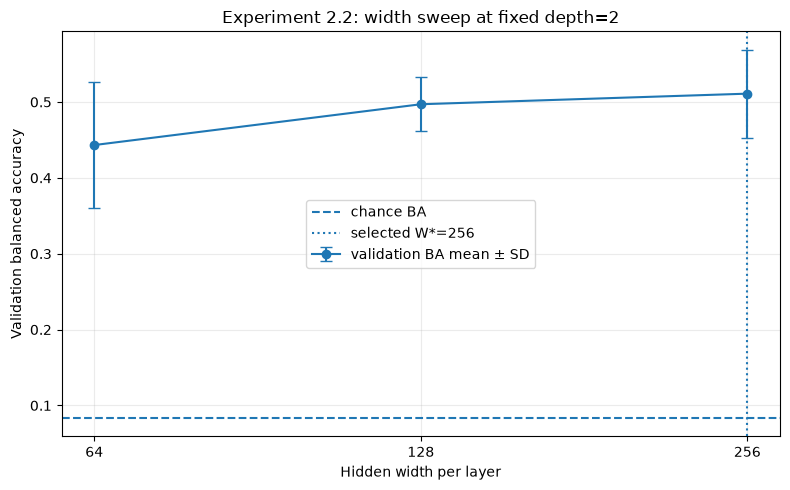

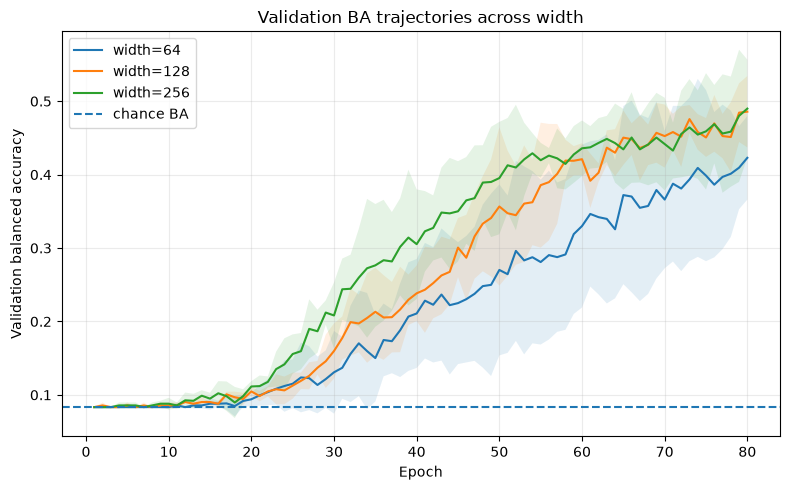

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    summary["width"],
    summary["mean_val_ba"],
    yerr=summary["sd_val_ba"].fillna(0),
    marker="o",
    capsize=4,
    label="validation BA mean ± SD",
)
ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.axvline(SELECTED_WIDTH, linestyle=":", label=f"selected W*={SELECTED_WIDTH}")
ax.set_xscale("log", base=2)
ax.set_xticks(list(WIDTHS))
ax.set_xticklabels([str(v) for v in WIDTHS])
ax.set_xlabel("Hidden width per layer")
ax.set_ylabel("Validation balanced accuracy")
ax.set_title("Experiment 2.2: width sweep at fixed depth=2")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for width in WIDTHS:
    sdf = histories[histories.width == width]
    curve = sdf.groupby("epoch")["val_balanced_accuracy"].agg(["mean", "std"])
    ax.plot(curve.index, curve["mean"], label=f"width={width}")
    ax.fill_between(
        curve.index,
        curve["mean"] - curve["std"].fillna(0),
        curve["mean"] + curve["std"].fillna(0),
        alpha=0.12,
    )
ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation balanced accuracy")
ax.set_title("Validation BA trajectories across width")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 14. Provenance

In [74]:
provenance = {
    "experiment_id": EXPERIMENT_ID,
    "phase": "B - backbone capacity",
    "parent_diagnostic": "experiment_2_1_1_timestep_relative10bin_temporal_order",
    "rationale": (
        f"Phase B measures backbone capacity under the configured {OBJECTIVE} readout"
    ),
    "dataset_roots": [str(Path(p).resolve()) for p in DATASET_ROOTS],
    "seeds": list(SEEDS),
    "split_seed": SPLIT_SEED,
    "included_labels": list(INCLUDED_LABELS),
    "class_to_idx": CLASS_TO_IDX,
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "event_representation": EVENT_REPRESENTATION,
    "event_feature_schema": EVENT_FEATURE_SCHEMA,
    "encoder_spec_sha256": ENCODER_SPEC_SHA256,
    "input_channels": INPUT_CHANNELS,
    "objective": OBJECTIVE,
    "relative_bin_count": N_RELATIVE_BINS,
    "widths": list(WIDTHS),
    "fixed_depth": FIXED_DEPTH,
    "tau_syn_ms": TAU_SYN_MS,
    "tau_mem_ms": TAU_MEM_MS,
    "alpha": ALPHA,
    "beta": BETA,
    "threshold": THRESHOLD,
    "surrogate_slope": SURROGATE_SLOPE,
    "reset_mechanism": RESET_MECHANISM,
    "snn_linear_bias": False,
    "learn_alpha": False,
    "learn_beta": False,
    "learn_threshold": False,
    "recurrence": False,
    "num_epochs": NUM_EPOCHS,
    "early_stopping": False,
    "checkpoint_selection": (
        "maximum validation balanced accuracy after full fixed epoch budget; "
        "tie-break by lower validation loss"
    ),
    "architecture_selection": (
        "highest mean validation balanced accuracy across seeds; exact tie -> smaller width"
    ),
    "test_used_for_architecture_selection": False,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "spike_regularization": SPIKE_REGULARIZATION,
}
with open(RESULTS_DIR / "experiment_2_2_provenance.json", "w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2, ensure_ascii=False)
print("Saved to:", RESULTS_DIR)

Saved to: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_2_2_width_sweep_relative10bin


## Decision rule

Use the validation summary to determine whether 2×64 is capacity-limited:

- Clear gain from 64 → 128, then saturation at 256: choose the width with highest mean validation BA and carry it into Experiment 2.3.
- Continued large gain through 256: Phase B has not yet demonstrated width saturation; consider extending the sweep before fixing `W*`.
- Little/no gain above 64: 2×64 is already sufficient for this readout and dataset.

Do **not** use test performance to override the width selected here.